# 📘 Week 10 복습과제 — Adam Optimizer 구현

> **Paper**: *Adam: A Method for Stochastic Optimization* (Kingma & Ba, 2015)  
> **제출 방법**: 빈칸을 채우고 셀을 모두 실행한 뒤 제출
> **예상 소요 시간**: 약 25~30분

---

### 📋 구성
| 섹션 | 내용 | 문제 유형 |
|------|------|-----------|
| 1 | 라이브러리 임포트 | — |
| 2 | 배경: Gradient Descent 계열 비교 | 서술형 |
| 3 | Adam 알고리즘 구현 (NumPy From Scratch) | 코드 빈칸 |
| 4 | Bias Correction 시각화 | 코드 빈칸 + 서술형 |
| 5 | 2D Loss Surface 궤적 비교 | 코드 빈칸 |
| 6 | PyTorch MNIST 학습 비교 | 코드 빈칸 + 서술형 |
| 7 | 하이퍼파라미터 민감도 분석 | 서술형 |

---
## 1. 라이브러리 임포트

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.colors import LogNorm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


---
## 2. 배경: Gradient Descent 계열 비교

| 방법 | 설명 | 단점 |
|---|---|---|
| **SGD** | 전체/일부 데이터로 gradient 계산 | 진동, 느린 수렴 |
| **Momentum** | 이전 gradient 방향을 누적 | 하이퍼파라미터 추가 |
| **RMSProp** | gradient 제곱의 이동평균으로 lr 조정 | 2차 모멘트만 사용 |
| **Adam** | Momentum + RMSProp + Bias correction | ✅ 가장 효과적 |

---
### ✏️ Q1 [서술형]

Adam은 **1차 모멘트(m)** 와 **2차 모멘트(v)** 를 모두 활용합니다.  
각각이 기존의 어떤 옵티마이저 아이디어에서 비롯된 것인지 설명하고,  
두 모멘트가 파라미터 업데이트 식에서 어떤 역할을 하는지 서술하세요.

```
📝 답안 작성란:
1차 모멘트 m 는 과거 gradient의 지수이동평균(EMA)으로, 이는 Momentum 기법에서 비롯된 개념. Momentum은 이전 gradient들을 누적하여 방향성을 부드럽게 만들고, 진동을 줄이면서 더 빠르게 최적점으로 수렴하도록 함. 따라서 m은 “어느 방향으로 계속 이동해야 하는가”를 결정하는 역할.

2차 모멘트 v 는 gradient의 제곱에 대한 지수이동평균으로, 이는 RMSProp (또는 AdaGrad 계열)에서 유래한 아이디. 이는 각 파라미터별 gradient 크기를 반영하여 학습률을 조정하는 방식. gradient가 큰 방향은 학습률을 줄이고, 작은 방향은 상대적으로 크게 유지하여 안정적인 학습을 가능하게 함.

이 두 모멘트는 Adam의 업데이트 식에서 함께 사용됨.
- m은 gradient의 방향을 안정적으로 추정하여 이동 방향을 결정하고
- v는 gradient 크기를 정규화하여 파라미터별로 학습률을 조절함

결과적으로 Adam은 Momentum의 빠른 수렴 성질과 RMSProp의 적응적 학습률 조정 능력을 결합하여, 빠르고 안정적인 최적화를 수행함.


```

---
## 3. Adam 알고리즘 구현 (NumPy — From Scratch)

논문의 Algorithm 1을 NumPy로 직접 구현합니다.  
아래 수식을 참고하여 빈칸을 채우세요.

$$m_t = \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot g_t$$
$$v_t = \beta_2 \cdot v_{t-1} + (1-\beta_2) \cdot g_t^2$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
$$\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

---
### 🔲 Q2 [코드 빈칸] — AdamOptimizer 클래스

아래 클래스에서 `###답안###` 으로 표시된 부분을 채우세요.

In [2]:
class AdamOptimizer:
    """
    Adam optimizer — NumPy 구현 (Kingma & Ba, 2015)

    Parameters
    ----------
    lr    : 학습률 α (default: 0.001)
    beta1 : 1차 모멘트 감쇠율 β₁ (default: 0.9)
    beta2 : 2차 모멘트 감쇠율 β₂ (default: 0.999)
    eps   : 수치 안정성 ε (default: 1e-8)
    """
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr    = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps   = eps
        self.m     = None   # 1차 모멘트 (Momentum)
        self.v     = None   # 2차 모멘트 (RMSProp)
        self.t     = 0      # 타임스텝

    def step(self, params, grads):
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)

        self.t += 1

        # 🔲 Q2-① : 1차 모멘트 업데이트 (biased)
        self.m = self.m = self.beta1 * self.m + (1 - self.beta1) * grads

        # 🔲 Q2-② : 2차 모멘트 업데이트 (biased)
        self.v = self.beta2 * self.v + (1 - self.beta2) * grads**2

        # Bias correction
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)

        # 🔲 Q2-③ : 파라미터 업데이트 수식
        params = params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params

/tmp/ipykernel_7960/1102948519.py:18: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/1102948519.py:18: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/1102948519.py:18: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/1102948519.py:18: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/1102948519.py:18: UserWarning: Glyph 49567 (\N{HANGUL SYLLABLE SOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarn

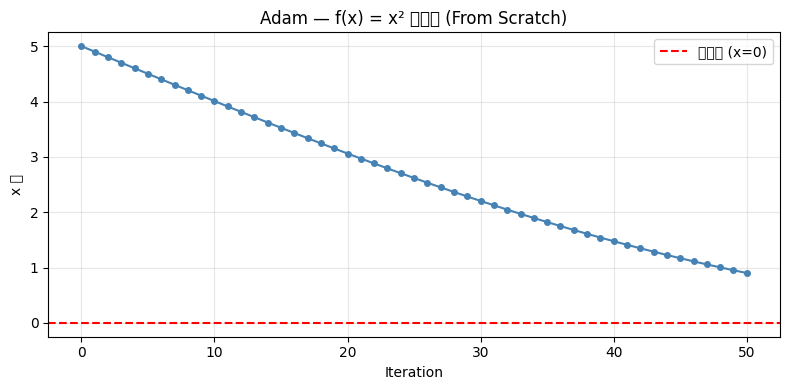

최종 x 값: 0.901119  (정답: 0)


In [3]:
# 동작 확인 — 1D 예시 (x² 최소화)
x = np.array([5.0])   # 초기값
optimizer = AdamOptimizer(lr=0.1)

history = [x[0]]
for _ in range(50):
    grad = 2 * x         # f(x) = x² → f'(x) = 2x
    x = optimizer.step(x, grad)
    history.append(x[0])

plt.figure(figsize=(8, 4))
plt.plot(history, 'o-', color='steelblue', markersize=4)
plt.axhline(0, color='red', linestyle='--', label='최솟값 (x=0)')
plt.title('Adam — f(x) = x² 최소화 (From Scratch)')
plt.xlabel('Iteration')
plt.ylabel('x 값')
plt.legend()
plt.tight_layout()
plt.show()
print(f'최종 x 값: {x[0]:.6f}  (정답: 0)')

---
## 4. Bias Correction 시각화

초기 타임스텝에서 모멘트가 0으로 초기화되어 있어 값이 **과소추정** 됩니다.  
Bias correction이 이를 어떻게 보정하는지 시각화합니다.

---
### 🔲 Q3 [코드 빈칸] — Bias Correction 보정값 계산

/tmp/ipykernel_7960/3506939099.py:41: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3506939099.py:41: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3506939099.py:41: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3506939099.py:41: UserWarning: Glyph 47704 (\N{HANGUL SYLLABLE MEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3506939099.py:41: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3506939099.py:41: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3506939099.py:41: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_la

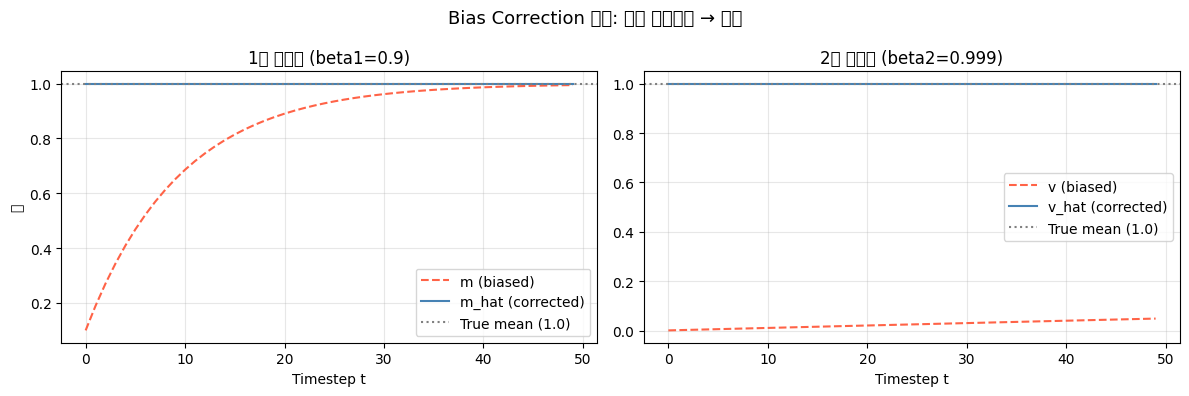

In [4]:
T = 50
beta1, beta2 = 0.9, 0.999

# 가상의 gradient (상수 1.0으로 가정)
g = 1.0
m, v = 0.0, 0.0

m_biased, v_biased = [], []
m_corrected, v_corrected = [], []

for t in range(1, T+1):
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * g**2

    m_biased.append(m)
    v_biased.append(v)

    # 🔲 Q3-① : bias correction 보정값 계산
    # 힌트: m_hat = m / (1 - beta1^t)
    m_corrected.append(m / (1 - beta1**t))
    v_corrected.append(v / (1 - beta2**t))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(m_biased,    label='m (biased)',    linestyle='--', color='tomato')
axes[0].plot(m_corrected, label='m_hat (corrected)', linestyle='-', color='steelblue')
axes[0].axhline(1.0, color='gray', linestyle=':', label='True mean (1.0)')
axes[0].set_title('1차 모멘트 (beta1=0.9)')
axes[0].set_xlabel('Timestep t')
axes[0].set_ylabel('값')
axes[0].legend()

axes[1].plot(v_biased,    label='v (biased)',    linestyle='--', color='tomato')
axes[1].plot(v_corrected, label='v_hat (corrected)', linestyle='-', color='steelblue')
axes[1].axhline(1.0, color='gray', linestyle=':', label='True mean (1.0)')
axes[1].set_title('2차 모멘트 (beta2=0.999)')
axes[1].set_xlabel('Timestep t')
axes[1].legend()

plt.suptitle('Bias Correction 효과: 초기 과소추정 → 보정', fontsize=13)
plt.tight_layout()
plt.show()

---
### ✏️ Q4 [서술형] — Bias Correction의 필요성

위 그래프에서 **biased 값** 과 **corrected 값** 의 차이를 관찰하세요.  
다음 두 가지를 서술하세요.

1. 왜 초기 타임스텝에서 biased 모멘트가 True mean보다 작게 나오는가? (초기화 값과 연결지어)
2. beta2=0.999인 2차 모멘트가 beta1=0.9인 1차 모멘트보다 bias correction 효과가 더 오래 지속되는 이유는?


📝 답안 작성란:

1. 초기 타임스텝에서 biased 모멘트가 True mean보다 작게 나오는 이유는, m과 v가 0으로 초기화되기 때문. Adam의 모멘트는 지수이동평균(EMA)으로 계산되는데, 초반에는 과거 값이 거의 없고 초기값 0의 영향이 크게 반영됨. 따라서 실제 gradient 평균이 1이라 하더라도, 초기에는 0과 섞이면서 값이 작게 추정되어 과소추정(bias) 이 발생함


2. $B_2=0.999$는 $B_1=0.9$보다 1에 훨씬 더 가깝기 때문에, 과거 값을 훨씬 더 강하게 유지하는 느린 업데이트(긴 메모리) 특성을 가짐. => 초기값 0의 영향이 더 오래 남아 있어 bias가 더 천천히 사라짐. 따라서 2차 모멘트 v는 1차 모멘트 m보다 bias correction의 필요성이 더 크고, 그 효과도 더 오래 지속됨.



---
## 5. 2D Loss Surface에서 옵티마이저 궤적 비교

**Beale function** 을 Loss surface로 사용하여  
SGD / Momentum / RMSProp / Adam 의 경로를 비교합니다.  
전역 최솟값: **(3, 0.5)**

In [5]:
# Loss function: Beale function
def beale(x, y):
    return ((1.5   - x + x*y   )**2 +
            (2.25  - x + x*y**2)**2 +
            (2.625 - x + x*y**3)**2)

def beale_grad(x, y):
    a = 1.5   - x + x*y;    da_dx = -1 + y;    da_dy = x
    b = 2.25  - x + x*y**2; db_dx = -1 + y**2; db_dy = 2*x*y
    c = 2.625 - x + x*y**3; dc_dx = -1 + y**3; dc_dy = 3*x*y**2
    gx = 2*(a*da_dx + b*db_dx + c*dc_dx)
    gy = 2*(a*da_dy + b*db_dy + c*dc_dy)
    return np.array([gx, gy])

---
### 🔲 Q5 [코드 빈칸] — Adam 궤적 시뮬레이션

아래 `run_optimizer` 함수에서 **Adam** 부분만 빈칸으로 되어 있습니다.  
Q2에서 구현한 수식을 참고하여 채우세요.

/tmp/ipykernel_7960/3677342823.py:69: UserWarning: Glyph 50741 (\N{HANGUL SYLLABLE OB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3677342823.py:69: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3677342823.py:69: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3677342823.py:69: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3677342823.py:69: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3677342823.py:69: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3677342823.py:69: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layou

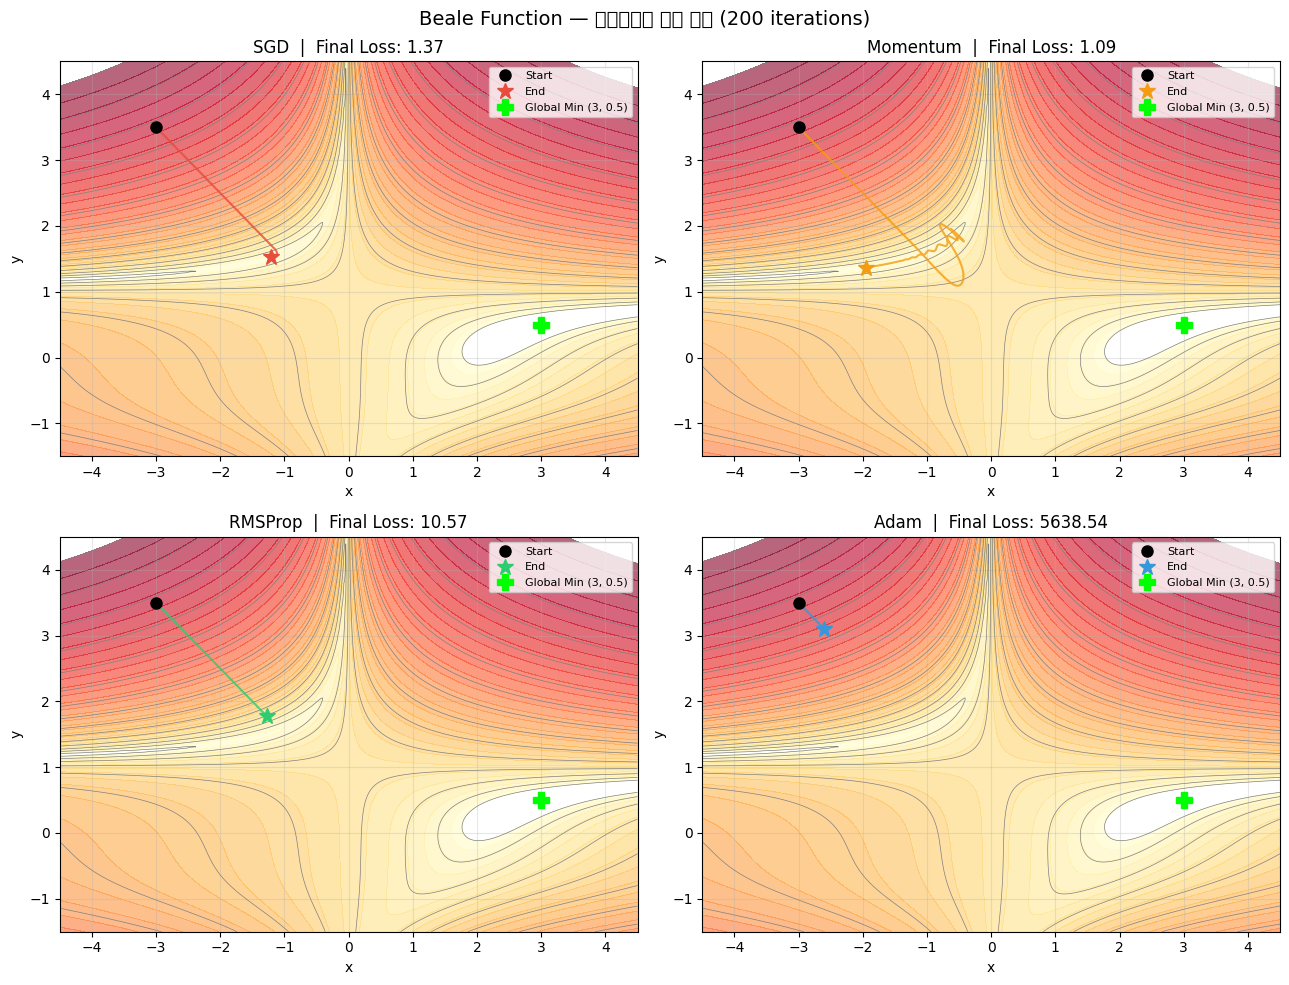

In [8]:
def run_optimizer(name, init, n_iter=200, lr=0.002):
    x = np.array(init, dtype=float)
    path = [x.copy()]

    m = np.zeros(2); v = np.zeros(2); t = 0
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    mu = 0.9

    for _ in range(n_iter):
        g = beale_grad(x[0], x[1])
        g = np.clip(g, -10, 10)

        if name == 'SGD':
            x = x - lr * g

        elif name == 'Momentum':
            m = mu * m + lr * g
            x = x - m

        elif name == 'RMSProp':
            v = beta2 * v + (1 - beta2) * g**2
            x = x - lr * g / (np.sqrt(v) + eps)

        elif name == 'Adam':
            t += 1
            # 🔲 Q5-① : 1차 모멘트 업데이트
            m = beta1 * m + (1 - beta1) * g
            # 🔲 Q5-② : 2차 모멘트 업데이트
            v = beta2 * v + (1 - beta2) * g**2
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            # 🔲 Q5-③ : 파라미터 업데이트
            x = x - lr * m_hat / (np.sqrt(v_hat) + eps)

        path.append(x.copy())
    return np.array(path)


# Loss surface 그리드
xs = np.linspace(-4.5, 4.5, 300)
ys = np.linspace(-1.5, 4.5, 300)
X, Y = np.meshgrid(xs, ys)
Z = beale(X, Y)

init_point = [-3.0, 3.5]
optimizers = ['SGD', 'Momentum', 'RMSProp', 'Adam']
colors     = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

paths = {name: run_optimizer(name, init_point) for name in optimizers}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, name, color in zip(axes, optimizers, colors):
    ax.contourf(X, Y, Z, levels=np.logspace(0, 5, 30), cmap='YlOrRd', alpha=0.6, norm=LogNorm())
    ax.contour( X, Y, Z, levels=np.logspace(0, 5, 15), colors='gray', linewidths=0.5, norm=LogNorm())
    path = paths[name]
    ax.plot(path[:, 0], path[:, 1], '-', color=color, linewidth=1.5, alpha=0.8)
    ax.plot(path[0, 0], path[0, 1], 'o', color='black', markersize=8, label='Start')
    ax.plot(path[-1, 0], path[-1, 1], '*', color=color, markersize=12, label='End')
    ax.plot(3, 0.5, 'P', color='lime', markersize=12, label='Global Min (3, 0.5)')
    final_loss = beale(path[-1, 0], path[-1, 1])
    ax.set_title(f'{name}  |  Final Loss: {final_loss:.2f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.set_xlim(-4.5, 4.5); ax.set_ylim(-1.5, 4.5)

plt.suptitle('Beale Function — 옵티마이저 궤적 비교 (200 iterations)', fontsize=14)
plt.tight_layout()
plt.show()

---
### ✏️ Q6 [서술형] — 궤적 비교 해석

위 4개의 궤적 그래프를 보고, 아래 질문에 답하세요.

SGD와 Adam의 궤적(경로 모양)이 다른 이유를 각 옵티마이저의 업데이트 방식과 연결지어 설명하세요.  
(단, Beale function은 비등방성(anisotropic) 곡면임을 참고하세요.)


📝 답안 작성란:
SGD와 Adam의 궤적이 다른 이유는 각 옵티마이저의 업데이트 방식과 학습률 조정 방식의 차이 때문.

- SGD는 단순히 현재 gradient에 비례하여 동일한 학습률로 파라미터를 업데이트. Beale function처럼 비등방성(anisotropic) 곡면에서는 방향마다 기울기 크기가 크게 다르기 때문에, SGD는 경사가 큰 방향으로 과도하게 움직이고 작은 방향으로는 느리게 이동하여 지그재그 형태의 비효율적인 경로를 보임.

- 반면 Adam은 1차 모멘트 m을 통해 gradient의 방향을 안정화하고(Momentum 효과), 2차 모멘트 v를 통해 각 파라미터별로 gradient 크기를 반영하여 학습률을 조정함(RMSProp 효과). 그 결과, 경사가 큰 방향에서는 업데이트 크기가 줄어들고, 작은 방향에서는 상대적으로 크게 유지되어 곡면의 스케일 차이를 보정함

따라서 Adam은 비등방성 구조에서도 진동을 줄이고 효율적인 방향으로 이동하여, SGD보다 더 부드럽고 빠르게 최적점으로 수렴하는 궤적을 보임

---
## 6. PyTorch로 MNIST 학습 — 옵티마이저별 수렴 속도 비교

같은 네트워크 구조에서 SGD / Momentum / RMSProp / Adam 의 수렴 속도를 비교합니다.

In [9]:
# 데이터 준비
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f'Train: {len(train_dataset):,}개 | Test: {len(test_dataset):,}개')

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.69MB/s]

Train: 60,000개 | Test: 10,000개


---
### 🔲 Q7 [코드 빈칸] — Adam 옵티마이저 설정 (논문 기본값)

아래 `train_model` 함수에서 Adam 옵티마이저 생성 부분을 논문 권장 기본값으로 채우세요.  
논문 권장값: **lr=0.001, β₁=0.9, β₂=0.999, ε=1e-8**

In [11]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def train_model(optimizer_name, n_epochs=10):
    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == 'Momentum':
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == 'RMSProp':
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    elif optimizer_name == 'Adam':
        # 🔲 Q7 : 논문 권장값으로 Adam 옵티마이저를 설정하세요
        optimizer = optim.Adam(model.parameters(),
                               lr=0.001,
                               betas=(0.9, 0.999),
                               eps=1e-8)

    train_losses, test_accs = [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X).argmax(dim=1)
                correct += (pred == y).sum().item()
        acc = correct / len(test_dataset) * 100
        test_accs.append(acc)

        print(f'[{optimizer_name}] Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Test Acc: {acc:.2f}%')

    return train_losses, test_accs

Device: cpu


In [12]:
# 4가지 옵티마이저 학습 실행
N_EPOCHS = 10
optimizer_names = ['SGD', 'Momentum', 'RMSProp', 'Adam']
colors_pt = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

results = {}
for name in optimizer_names:
    print(f'\n' + '='*50)
    torch.manual_seed(SEED)
    results[name] = train_model(name, N_EPOCHS)


[SGD] Epoch  1 | Loss: 1.7052 | Test Acc: 82.23%
[SGD] Epoch  2 | Loss: 0.6324 | Test Acc: 88.00%
[SGD] Epoch  3 | Loss: 0.4310 | Test Acc: 89.55%
[SGD] Epoch  4 | Loss: 0.3686 | Test Acc: 90.23%
[SGD] Epoch  5 | Loss: 0.3350 | Test Acc: 91.26%
[SGD] Epoch  6 | Loss: 0.3118 | Test Acc: 91.67%
[SGD] Epoch  7 | Loss: 0.2939 | Test Acc: 91.93%
[SGD] Epoch  8 | Loss: 0.2789 | Test Acc: 92.41%
[SGD] Epoch  9 | Loss: 0.2654 | Test Acc: 92.78%
[SGD] Epoch 10 | Loss: 0.2539 | Test Acc: 92.94%

[Momentum] Epoch  1 | Loss: 0.6207 | Test Acc: 92.57%
[Momentum] Epoch  2 | Loss: 0.2281 | Test Acc: 94.38%
[Momentum] Epoch  3 | Loss: 0.1653 | Test Acc: 95.84%
[Momentum] Epoch  4 | Loss: 0.1274 | Test Acc: 96.48%
[Momentum] Epoch  5 | Loss: 0.1035 | Test Acc: 96.91%
[Momentum] Epoch  6 | Loss: 0.0844 | Test Acc: 97.13%
[Momentum] Epoch  7 | Loss: 0.0714 | Test Acc: 97.43%
[Momentum] Epoch  8 | Loss: 0.0610 | Test Acc: 97.44%
[Momentum] Epoch  9 | Loss: 0.0528 | Test Acc: 97.80%
[Momentum] Epoch 10 | 

/tmp/ipykernel_7960/3372305724.py:19: UserWarning: Glyph 50741 (\N{HANGUL SYLLABLE OB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3372305724.py:19: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3372305724.py:19: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3372305724.py:19: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3372305724.py:19: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3372305724.py:19: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7960/3372305724.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

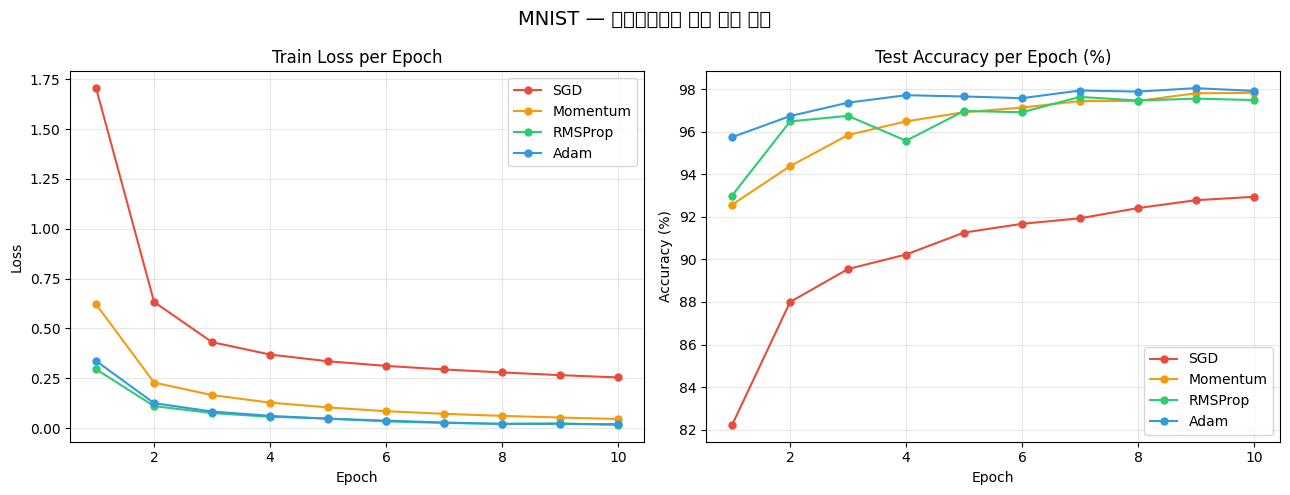


📊 최종 성능 요약 (Epoch 10)
Optimizer      Train Loss   Test Acc
------------------------------------
SGD                0.2539     92.94%
Momentum           0.0453     97.82%
RMSProp            0.0158     97.48%
Adam               0.0190     97.91%


In [13]:
# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs = range(1, N_EPOCHS + 1)

for name, color in zip(optimizer_names, colors_pt):
    losses, accs = results[name]
    axes[0].plot(epochs, losses, '-o', label=name, color=color, markersize=5)
    axes[1].plot(epochs, accs,   '-o', label=name, color=color, markersize=5)

axes[0].set_title('Train Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Test Accuracy per Epoch (%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.suptitle('MNIST — 옵티마이저별 수렴 속도 비교', fontsize=14)
plt.tight_layout()
plt.show()

print('\n📊 최종 성능 요약 (Epoch 10)')
print(f'{"Optimizer":<12} {"Train Loss":>12} {"Test Acc":>10}')
print('-' * 36)
for name in optimizer_names:
    losses, accs = results[name]
    print(f'{name:<12} {losses[-1]:>12.4f} {accs[-1]:>9.2f}%')

---
### ✏️ Q8 [서술형] — MNIST 결과 해석

위 학습 결과를 보고 다음을 서술하세요.

RMSProp의 Train Loss가 Adam보다 낮음에도 Test Accuracy는 Adam보다 낮은 경향이 나타납니다.  
이 현상이 나타날 수 있는 이유를 **generalization** 관점에서 설명하고,  
Adam이 RMSProp보다 일반화 성능이 좋을 수 있는 이유를 한 가지 이상 서술하세요.


📝 답안 작성란:

RMSProp의 Train Loss가 Adam보다 낮지만 Test Accuracy는 더 낮게 나타나는 현상은 generalization(일반화) 관점에서 설명할 수 있음. Train Loss가 낮다는 것은 학습 데이터에 매우 잘 맞추고 있다는 의미지만, 이는 동시에 훈련 데이터에 과도하게 적합(overfitting) 되었을 가능성을 의미함. 즉, RMSProp은 학습 데이터의 패턴뿐 아니라 노이즈까지 학습하여, 보지 못한 test 데이터에서는 성능이 떨어질 수 있음.

반면 Adam은 1차 모멘트 m을 통한 Momentum 효과와 2차 모멘트 v를 통한 adaptive learning rate 조정을 동시에 사용함. 이 과정에서 gradient 방향이 안정화되고, 파라미터 업데이트가 과도하게 특정 방향으로 치우치는 것을 방지하여 더 균형 잡힌 최적점으로 수렴하게 됨.

또한 Adam의 bias correction과 모멘트 기반 업데이트는 초기 학습을 안정적으로 만들고, 급격한 파라미터 변화나 과적합을 완화하는 효과를 줄 수 있음. 그 결과 RMSProp보다 덜 과적합되고, test 데이터에 대해 더 좋은 일반화 성능을 보일 수 있음

-> 요약하면, RMSProp은 train 데이터에 더 잘 맞추지만 과적합 위험이 크고, Adam은 더 안정적이고 균형 잡힌 학습을 통해 일반화 성능이 더 우수할 수 있음

---
## 7. 하이퍼파라미터 민감도 분석

논문 권장 default: **α=0.001, β₁=0.9, β₂=0.999, ε=1e-8**

---
### 🔲 Q9 [코드 빈칸] — 학습률(lr) 민감도 실험

학습률 실험 중...
  lr=0.1
  lr=0.01
  lr=0.001
  lr=0.0001


/tmp/ipykernel_7960/2853393602.py:37: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/2853393602.py:37: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/2853393602.py:37: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/2853393602.py:37: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/2853393602.py:37: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/2853393602.py:37: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/2853393602.py:37: UserWarning: 

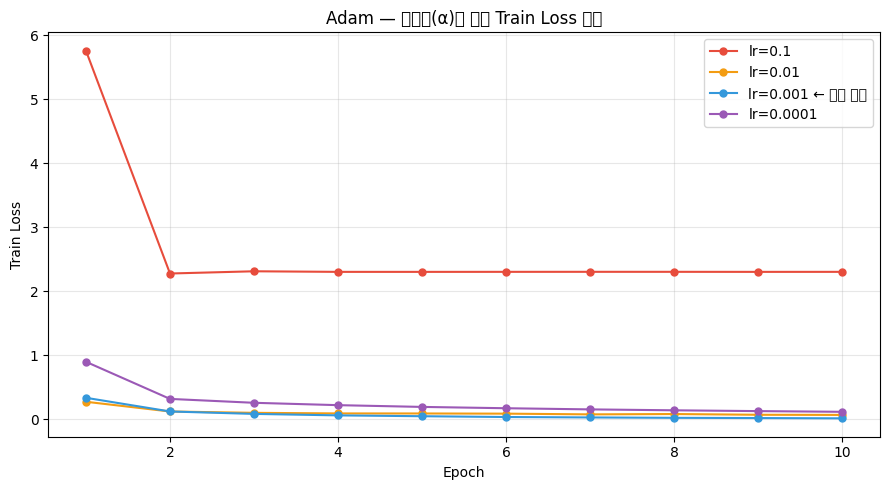

In [14]:
def train_adam_with_lr(lr, n_epochs=10):
    torch.manual_seed(SEED)
    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()
    # 🔲 Q9 : lr 인자를 사용해 Adam 옵티마이저를 생성하세요
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(n_epochs):
        model.train()
        total = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            total += loss.item()
        losses.append(total / len(train_loader))
    return losses

lr_values = [0.1, 0.01, 0.001, 0.0001]
lr_colors = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']

print('학습률 실험 중...')
lr_results = {}
for lr in lr_values:
    print(f'  lr={lr}')
    lr_results[lr] = train_adam_with_lr(lr)

plt.figure(figsize=(9, 5))
for lr, color in zip(lr_values, lr_colors):
    label = f'lr={lr}' + (' ← 논문 권장' if lr == 0.001 else '')
    plt.plot(range(1, 11), lr_results[lr], '-o', label=label, color=color, markersize=5)

plt.title('Adam — 학습률(α)에 따른 Train Loss 변화')
plt.xlabel('Epoch'); plt.ylabel('Train Loss')
plt.legend(); plt.tight_layout()
plt.show()

β₁ 실험 중...
  β₁=0.5
  β₁=0.7
  β₁=0.9
  β₁=0.95


/tmp/ipykernel_7960/1187731614.py:35: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/1187731614.py:35: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/1187731614.py:35: UserWarning: Glyph 47704 (\N{HANGUL SYLLABLE MEN}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/1187731614.py:35: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/1187731614.py:35: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/1187731614.py:35: UserWarning: Glyph 49632 (\N{HANGUL SYLLABLE SOE}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout()
/tmp/ipykernel_7960/1187731614.py:35: UserWarning: Gly

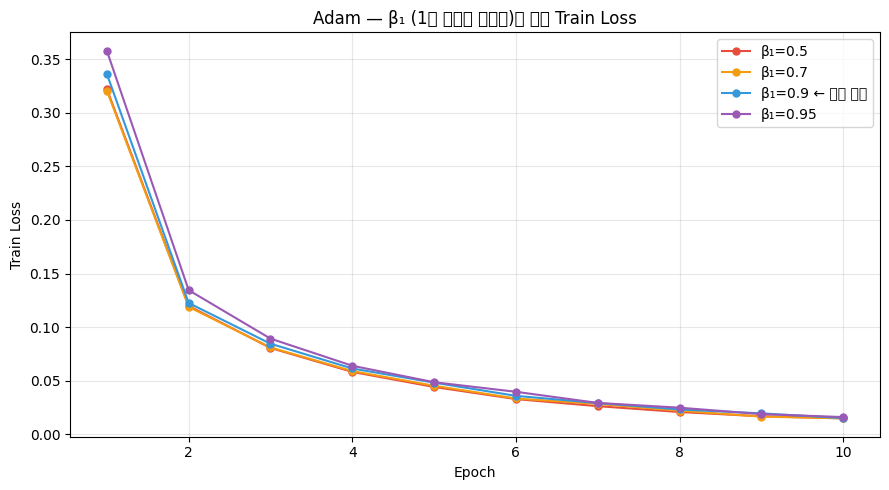


💡 논문 권장 하이퍼파라미터:
   α  = 0.001
   β₁ = 0.9
   β₂ = 0.999
   ε  = 1e-8


In [15]:
# β₁ 변화에 따른 영향
def train_adam_with_beta1(beta1, n_epochs=10):
    torch.manual_seed(SEED)
    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(beta1, 0.999))
    losses = []
    for _ in range(n_epochs):
        model.train(); total = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward(); optimizer.step()
            total += loss.item()
        losses.append(total / len(train_loader))
    return losses

beta1_values = [0.5, 0.7, 0.9, 0.95]
beta1_colors = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']

print('β₁ 실험 중...')
beta1_results = {}
for b1 in beta1_values:
    print(f'  β₁={b1}')
    beta1_results[b1] = train_adam_with_beta1(b1)

plt.figure(figsize=(9, 5))
for b1, color in zip(beta1_values, beta1_colors):
    label = f'β₁={b1}' + (' ← 논문 권장' if b1 == 0.9 else '')
    plt.plot(range(1, 11), beta1_results[b1], '-o', label=label, color=color, markersize=5)

plt.title('Adam — β₁ (1차 모멘트 감쇠율)에 따른 Train Loss')
plt.xlabel('Epoch'); plt.ylabel('Train Loss')
plt.legend(); plt.tight_layout()
plt.show()

print('\n💡 논문 권장 하이퍼파라미터:')
print('   α  = 0.001')
print('   β₁ = 0.9')
print('   β₂ = 0.999')
print('   ε  = 1e-8')

---
### ✏️ Q10 [서술형] — 하이퍼파라미터 분석

위 두 실험(lr 민감도, β₁ 민감도) 그래프를 보고 아래 질문에 답하세요.

1. **lr=0.1** 일 때 loss가 수렴하지 않고 높게 유지되는 이유를 수식과 연결지어 설명하세요.
2. **β₁=0.5** 일 때 β₁=0.9에 비해 학습이 덜 안정적인 이유는 무엇인가요?


📝 답안 작성란:

1. Adam의 파라미터 업데이트 식은 다음과 같다.

  $$
\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
  $$

  여기서 $\alpha$ (learning rate)가 너무 크면,
  $$
  \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
  $$
  항이 커져 한 번의 업데이트 크기가 과도하게 증가

  그 결과 최적점 주변에서도 파라미터가 최소값을 지나치게 되어(overshooting),loss가 수렴하지 않고 진동하거나 발산하게 됨


2. $B_1$은 1차 모멘트(gradient의 EMA)에서 과거 gradient를 얼마나 반영할지를 결정하는 파라미터.$B_1=0.5$는 $B_1=0.9$보다 과거 정보를 덜 반영하고, 현재 gradient에 더 민감하게 반응함. 그 결과 gradient 방향이 매 step마다 크게 변하면서 Momentum 효과가 약해지고, 업데이트 방향이 불안정해져 진동이 커짐.

반면$B_1=0.9$는 과거 gradient를 충분히 누적하여 방향을 부드럽게 만들어 주므로, 노이즈가 있는 gradient에서도 더 안정적이고 일관된 방향으로 수렴할 수 있음. 따라서$B_1$이 작을수록 학습은 더 불안정해지고, 클수록 안정적인 수렴을 보이게 됨



---
## 📋 제출 전 체크리스트

- [ ] Q2 `AdamOptimizer.step()` — 모멘트 업데이트 & 파라미터 업데이트 빈칸 완성
- [ ] Q3 Bias Correction 보정값 계산 빈칸 완성
- [ ] Q5 Adam 궤적 시뮬레이션 빈칸 완성
- [ ] Q7 PyTorch Adam 하이퍼파라미터 빈칸 완성
- [ ] Q9 학습률 민감도 실험 빈칸 완성
- [ ] Q1, Q4, Q6, Q8, Q10 서술형 답안 작성
- [ ] 모든 셀 실행 완료 (Run All)

---
**참고 자료**: Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR 2015.